> ### **Building with Sarvam**
>
> **An open teaching kit for the Sarvam AI stack.**
>
> Notebook maintained by **Dr. Bhaveshkumar C. Dharmani** — Founder & AI Mentor, AIVidhya4Sarvam.
PhD (ICT), DA-IICT Gandhinagar · https://www.aividhya.in/ · https://www.aividhya4sarvam.in/ · bhavesh@aividhya.in · https://www.linkedin.com/in/bhaveshdharmani/
>
> Drafted with AI assistance and stress-tested cell by cell in live workshop sessions. Runs against your own Sarvam API key from dashboard.sarvam.ai, with a live ₹ cost meter after every call.
>
> Apache 2.0 · Issues and PRs welcome at github.com/dharmanibc/building-with-sarvam.

<div style="background:#12172E;color:#fff;padding:20px 24px;border-radius:8px">
<div style="color:#FF8A3D;font-size:12px;letter-spacing:2px;font-weight:700">LAB 09 · INTEROP</div>
<div style="font-size:26px;font-weight:700;margin-top:6px">Your existing framework, Sarvam underneath</div>
<div style="color:#FFB37A;font-size:14px;margin-top:8px">LangChain · LangGraph · CrewAI · n8n — same task, four orchestrators, one endpoint</div>
</div>

**Time:** 75 min &nbsp;·&nbsp; **Est. cost:** ≈ ₹6 &nbsp;·&nbsp; **Prereq:** Labs 00, 05, 07

In [1]:
# ── Standard lab header. Run this first in every notebook. ─────────────────
import os, sys, json, time, math, wave, io
from pathlib import Path

# pip install sarvamai python-dotenv

from dotenv import load_dotenv, find_dotenv
# Finds your key without hardcoding anyone's filesystem. Tried in order:
#   1. SARVAM_API_KEY already set in the environment
#   2. the file named by SARVAM_ENV_FILE, if you set that variable
#   3. a .env beside this notebook, or in any parent folder
load_dotenv(os.environ.get("SARVAM_ENV_FILE") or find_dotenv(usecwd=True))

API_KEY = os.environ.get("SARVAM_API_KEY")
assert API_KEY, (
    "SARVAM_API_KEY not found.\\n"
    "Create a .env next to this notebook containing:  SARVAM_API_KEY=sk_...\\n"
    "or point SARVAM_ENV_FILE at an existing env file.\\n"
    "Free key + Rs 1000 credit: https://indus.sarvam.ai/"
)

from sarvamai import SarvamAI

client = SarvamAI(api_subscription_key=API_KEY)
DATA = Path("./data"); DATA.mkdir(exist_ok=True)
OUT  = Path("./out");  OUT.mkdir(exist_ok=True)
print("SDK ready ·", sys.version.split()[0])

SDK ready · 3.13.9


In [2]:
# ── The ₹ meter, imported ─────────────────────────────────────────────────
# Lab 00 writes cost_meter.py next to these notebooks. If this import fails,
# run Lab 00 once — it is the only lab that defines the meter.
try:
    from cost_meter import CostMeter, RATES, FREE_CREDIT
except ImportError:
    raise ImportError(
        "cost_meter.py not found.\n"
        "Run 00_Setup_and_the_Cost_Meter.ipynb once — its last section writes "
        "cost_meter.py into this folder, and every other lab imports it from there."
    )

cost = CostMeter()
print(f"cost meter armed · rates dated Aug 2026 · ₹{FREE_CREDIT:.0f} free credit")


cost meter armed · rates dated Aug 2026 · ₹1000 free credit


## The whole lab in one sentence

Sarvam speaks the OpenAI wire protocol on `/v1/chat/completions` and ships a
standard MCP server on `uvx sarvam-mcp`. **Every framework built on either of
those two contracts inherits Sarvam with a one-line configuration change.**

This notebook proves that for the four orchestrators most Indian teams already
ship on. Each section is 15 minutes, self-contained, and prints rupees. If you
already know one of the four, you can skip to the ones you do not.

> **Prereqs.** Lab 00's cost meter is loaded above. You need `SARVAM_API_KEY` and
> Python 3.10+. Framework installs are called out inline — pip in this cell as
> you go, or run this once up front:
>
> ```bash
> pip install langchain langchain-openai langgraph langchain-mcp-adapters \
>             crewai crewai-tools httpx
> ```
>
> **The MCP walkthroughs** shell out to `uvx sarvam-mcp` (installed on first run
> from PyPI). On a fresh machine, `pip install uv` first — the `uvx` command
> lives in the `uv` package. If MCP is blocked in your environment (offline
> workshop, corporate proxy), each MCP cell has a plain-SDK fallback marked
> `# no-MCP fallback` — the lab still runs end-to-end.

---
## 0 · Prove the endpoint works from the raw OpenAI SDK

Before adding any framework, do the one-line swap on the vanilla `openai`
library. If this cell works, everything downstream is guaranteed to work —
because everything downstream is *this cell* with a wrapper on top.

In [3]:
# pip install openai
from openai import OpenAI

raw = OpenAI(base_url="https://api.sarvam.ai/v1", api_key=API_KEY)

r = raw.chat.completions.create(
    model    = "sarvam-105b",
    messages = [{"role": "user", "content": "One sentence: what is a सूत्र?"}],
    max_tokens = 1000,
)
print(r.choices[0].message.content)
print(r.usage.prompt_tokens, r.usage.completion_tokens)
cost.llm(r.usage.prompt_tokens, r.usage.completion_tokens)

None
18 1000


0.07372704

That is the entire trick. `base_url + api_key + model` and the OpenAI SDK is now
a Sarvam SDK. Every framework in the next four sections is doing exactly this
underneath — you are only changing what wraps it.

---
## 1 · LangChain — `ChatOpenAI` is already a Sarvam client

**Time: 15 min. Cost: ~₹1.**

`langchain-openai` is a thin wrapper around the OpenAI SDK. The same swap works
verbatim — every LangChain construct (prompts, chains, agents, structured
output, streaming, tool binding) inherits Sarvam without modification.

```bash
pip install langchain langchain-openai
```

In [4]:
# %pip install langchain langchain-openai

In [5]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage

llm = ChatOpenAI(
    model      = "sarvam-105b",
    base_url   = "https://api.sarvam.ai/v1",
    api_key    = API_KEY,
    temperature= 0.2,
    max_tokens = 400,
    reasoning_effort = None, # now a declared field on ChatOpenAI
    # Sarvam-specific arg — LangChain passes it through model_kwargs 
    # model_kwargs = {"reasoning_effort": None},
)

reply = llm.invoke([
    SystemMessage("You are a concise NBFC agent. One sentence, in the caller's language."),
    HumanMessage("मेरी अगली EMI कब देय है?"),
])
print(reply.content)
# LangChain surfaces usage under .usage_metadata on newer versions
u = reply.usage_metadata or {}
cost.llm(u.get("input_tokens", 0), u.get("output_tokens", 0))

कृपया अपना लोन अकाउंट नंबर या रजिस्टर्ड मोबाइल नंबर शेयर करें, ताकि मैं आपकी अगली EMI की देय तिथि देख सकूँ।


0.03414048

### 1.1  Tool binding — the standard `@tool` decorator, unchanged

In [6]:
from langchain_core.tools import tool

ACCOUNTS = {"LN1001": {"name": "Rajesh Kumar", "emi": 12500, "due": "15 अगस्त"}}

@tool
def get_account(account_id: str) -> dict:
    """Look up an NBFC loan account by its ID (e.g. LN1001)."""
    return ACCOUNTS.get(account_id, {"error": "not found"})

llm_with_tools = llm.bind_tools([get_account])

msg = llm_with_tools.invoke("The caller's account is LN1001. When is the next EMI?")
# print("Response: ", msg.content)
print("tool_calls:", msg.tool_calls)
u = msg.usage_metadata or {}
cost.llm(u.get("input_tokens", 0), u.get("output_tokens", 0))

tool_calls: [{'name': 'get_account', 'args': {'account_id': 'LN1001'}, 'id': 'call_d9b034a447fb4cea8cc0e1a7', 'type': 'tool_call'}]


0.00934032

The `tool_calls` list follows OpenAI's standard shape. Every LangChain agent
class (`create_openai_tools_agent`, `create_tool_calling_agent`,
`create_react_agent` from LangGraph) speaks that shape natively — you can hand
this LLM to any of them and it will drive tools correctly.

### 1.2  Sarvam MCP through the LangChain MCP adapter

Same LLM, plus the 14 tools from `sarvam-mcp` — STT, TTS, translate, LID,
vision, pronunciation — appearing as ordinary LangChain tools.

```bash
pip install langchain-mcp-adapters
# and:  pip install uv   (provides the `uvx` command sarvam-mcp launches with)
```

In [7]:
# %pip install langchain-mcp-adapters

In [8]:
try:
    from langchain_mcp_adapters.client import MultiServerMCPClient
    _HAVE_LC_MCP = True
except ImportError:
    _HAVE_LC_MCP = False
    print("langchain-mcp-adapters not installed — skipping MCP demo")

if _HAVE_LC_MCP:
    mcp = MultiServerMCPClient({
        "sarvam": {
            "command":   "uvx",
            "args":      ["sarvam-mcp"],
            "transport": "stdio",
            "env":       {"SARVAM_API_KEY": API_KEY},
        }
    })
    try:
        tools = await mcp.get_tools()
        print(f"loaded {len(tools)} Sarvam tools via MCP")
        for t in tools[:]:
            print(f"  ·{t.name:<28} {t.description[:60]}")
        print("  ...")
    except Exception as e:
        print(f"MCP server did not start ({e.__class__.__name__}: {e}).")
        print("Common fixes: install uv (`pip install uv`), or set transport='stdio' explicitly.")

loaded 30 Sarvam tools via MCP
  ·sarvam_tools_set_api_key     Set or update your Sarvam API key. Call this if you get an
a
  ·sarvam_tools_upgrade         Check for updates and upgrade sarvam-mcp to the latest versi
  ·sarvam_tools_stt_transcribe  Runtime tool — calls Sarvam API now. For code-writing help, 
  ·sarvam_tools_stt_translate   Runtime tool — calls Sarvam API now. For code-writing help, 
  ·sarvam_tools_stt_batch_submit Runtime tool — calls Sarvam API now. For code-writing help, 
  ·sarvam_tools_stt_batch_status Runtime tool — calls Sarvam API now.

Poll the status of a b
  ·sarvam_tools_tts_speak       Runtime tool — calls Sarvam API now. For code-writing help, 
  ·sarvam_tools_tts_stream      Runtime tool — calls Sarvam API now. For code-writing help, 
  ·sarvam_tools_translate       Runtime tool — calls Sarvam API now. For code-writing help, 
  ·sarvam_tools_transliterate   Runtime tool — calls Sarvam API now. For code-writing help, 
  ·sarvam_tools_identify_language Run

In [9]:
# Bind the MCP tools to any React-style agent and let it choose
if _HAVE_LC_MCP and 'tools' in dir() and tools:
    
    # from langgraph.prebuilt import create_react_agent
    # agent = create_react_agent(llm, tools=tools)
    
    from langchain.agents import create_agent
    agent = create_agent(llm, tools=tools)
    try:
        out = await agent.ainvoke({"messages": [
            {"role": "user",
             "content": "Translate 'Independence Day is on 15 August' to Hindi using the sarvam_translate tool. Return only the Hindi text."}
        ]})
        print(out["messages"][-1].content)
        # Rough cost — MCP tools do NOT report token usage back through LangChain,
        # so we credit ~800 tokens per hop as a conservative estimate.
        cost.llm(800, 200, 0)
        cost.text(50, kind="translate")
    except Exception as e:
        print(f"agent invoke failed: {e}")
else:
    # no-MCP fallback — call translate through the SDK directly
    r = client.text.translate(input="Independence Day is on 15 August",
                              source_language_code="en-IN",
                              target_language_code="hi-IN",
                              model="mayura:v1")
    print(r.translated_text); cost.text(50, kind="translate")

agent invoke failed: Error code: 400 - {'error': {'message': 'body.messages.2.tool.content : Input should be a valid string', 'code': 'invalid_request_error', 'request_id': '20260828_45bd32fe-e209-41ce-80a6-453c8f8235e4'}}


### Reason for the Error-code 400: 
langchain-mcp-adapters 0.3.2 always converts a successful MCP tool result into a list of content blocks ([{"type": "text", "text": ...}]), and langchain-openai passes that list straight through onto the wire as "content": [...]. Sarvam's chat endpoint requires tool-role message content to be a plain string (this is actually closer to OpenAI's real schema than the newer LangChain content-blocks convention is), so it rejects it with the 400 you saw. This isn't really "Sarvam being unusually strict" — it's a genuine interop gap between LangChain's newer multimodal content-block model and providers that still expect the classic string-only tool message shape.

In [10]:
if _HAVE_LC_MCP:
    # ⚠️ langchain-mcp-adapters 0.3+ always converts a successful MCP result
    # into a LIST of content blocks ([{"type": "text", "text": ...}]), and
    # langchain-openai passes that list straight through as the `tool`
    # message's `content`. Sarvam's chat endpoint requires `content` to be a
    # plain string there and 400s with "Input should be a valid string".
    # Fix via the officially supported extension point — a tool_interceptor
    # that flattens the result back to text before it reaches the wire.
    #
    # ⚠️ Named `mcp_fixed`/`tools_fixed` (not `mcp`/`tools`) on purpose. The
    # cells above built a client and tool list WITHOUT the interceptor. If
    # this cell reused those names, whichever cell you last ran would decide
    # what "tools" points to — re-running things out of order (or leaving
    # the fetch commented out, as happened here) silently falls back to the
    # unintercepted tools and looks exactly like "the interceptor stopped
    # working" when it in fact never ran. Every cell below that wants the
    # fix must use `tools_fixed` explicitly.

    from mcp.types import CallToolResult
    from langchain_core.messages import ToolMessage

    async def stringify_tool_content(request, handler):
        result = await handler(request)
        # ⚠️ Cover BOTH outcomes — the original version only handled
        # `not result.isError`, so a genuinely FAILED tool call still fell
        # through with list-shaped content and re-triggered the same 400.
        if isinstance(result, CallToolResult):
            text = "\n".join(
                block.text for block in result.content
                if getattr(block, "type", None) == "text"
            )
            # request.runtime is the injected ToolRuntime — carries the real
            # tool_call_id so the returned ToolMessage still links correctly.
            tool_call_id = getattr(request.runtime, "tool_call_id", None) or ""
            status = "error" if result.isError else "success"
            return ToolMessage(content=text or f"({status}, no text content)",
                               tool_call_id=tool_call_id, status=status)
        return result

    mcp_fixed = MultiServerMCPClient({
        "sarvam": {
            "command":   "uvx",
            "args":      ["sarvam-mcp"],
            "transport": "stdio",
            "env":       {"SARVAM_API_KEY": API_KEY},
        }
    }, tool_interceptors=[stringify_tool_content])
    try:
        tools_fixed = await mcp_fixed.get_tools()
        print(f"loaded {len(tools_fixed)} Sarvam tools via MCP (with interceptor)")
        for t in tools_fixed[:6]:
            print(f"  · {t.name:<28} {t.description[:60]}")
        print("  ...")
    except Exception as e:
        tools_fixed = None
        print(f"MCP server did not start ({e.__class__.__name__}: {e}).")
        print("Common fixes: install uv (`pip install uv`), or set transport='stdio' explicitly.")


loaded 30 Sarvam tools via MCP (with interceptor)
  · sarvam_tools_set_api_key     Set or update your Sarvam API key. Call this if you get an
a
  · sarvam_tools_upgrade         Check for updates and upgrade sarvam-mcp to the latest versi
  · sarvam_tools_stt_transcribe  Runtime tool — calls Sarvam API now. For code-writing help, 
  · sarvam_tools_stt_translate   Runtime tool — calls Sarvam API now. For code-writing help, 
  · sarvam_tools_stt_batch_submit Runtime tool — calls Sarvam API now. For code-writing help, 
  · sarvam_tools_stt_batch_status Runtime tool — calls Sarvam API now.

Poll the status of a b
  ...


In [11]:
# Bind the FIXED MCP tools (tools_fixed, from the interceptor cell above) to
# a React-style agent and let it choose.
if _HAVE_LC_MCP and 'tools_fixed' in dir() and tools_fixed:

    # from langgraph.prebuilt import create_react_agent
    # agent = create_react_agent(llm, tools=tools_fixed)

    from langchain.agents import create_agent
    agent = create_agent(llm, tools=tools_fixed)
    try:
        out = await agent.ainvoke({"messages": [
            {"role": "user",
             "content": "Translate 'Independence Day is on 15 August' to Hindi using the sarvam_translate tool. Return only the Hindi text."}
        ]})
        print(out["messages"][-1].content)
        # Rough cost — MCP tools do NOT report token usage back through LangChain,
        # so we credit ~800 tokens per hop as a conservative estimate.
        cost.llm(800, 200, 0)
        cost.text(50, kind="translate")
    except Exception as e:
        print(f"agent invoke failed: {e}")
else:
    # no-MCP fallback — call translate through the SDK directly
    r = client.text.translate(input="Independence Day is on 15 August",
                              source_language_code="en-IN",
                              target_language_code="hi-IN",
                              model="mayura:v1")
    print(r.translated_text); cost.text(50, kind="translate")

15 अगस्त को स्वतंत्रता दिवस होता है।


In [12]:
# If MCP is available, wire the same FIXED tools (tools_fixed) into a full React loop.
if _HAVE_LC_MCP and 'tools_fixed' in dir() and tools_fixed:

    # from langgraph.prebuilt import create_react_agent      # LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`.
    # react = create_react_agent(llm, tools=tools_fixed)     # Deprecated in LangGraph V1.0 to be removed in V2.0.

    from langchain.agents import create_agent
    react = create_agent(llm, tools=tools_fixed)
    try:
        out = await react.ainvoke({"messages": [
            {"role": "user",
             "content": ("Identify the language of this text and then translate it to English: "
                         "'நமஸ்தே, என்னுடைய கடன் விவரங்கள் என்ன?'. Use the appropriate MCP tools.")}
        ]})
        print(out["messages"][-1].content)
        cost.llm(1200, 300, 0); cost.text(60, kind="translate"); cost.text(60, kind="lid")
    except Exception as e:
        print(f"react agent failed: {e}")
else:
    print("(MCP unavailable — skipped; the plain-LangGraph example above is what the segment tests.)")


**Identified Language:** Tamil (Tamil Nadu, India — `ta-IN`)

**Translation to English:**
> "Hello, what is my credit information?"


**What just happened.** The agent read your prompt, looked at the 14 MCP tool
schemas, picked `sarvam_translate`, called it with the right arguments, and
returned the Hindi string — with zero glue code from you. That is the *value* of
MCP: Sarvam's non-chat surface (STT/TTS/vision/pronunciation) becomes part of
your agent's tool palette without a single wrapper written on your side.

---
## 2 · LangGraph — same LLM, the graph you already know

**Time: 15 min. Cost: ~₹1.**

LangGraph is orchestration, not a model layer — it reuses your LangChain
`ChatOpenAI` as-is. Any StateGraph, checkpointer, interrupt, or human-in-the-loop
pattern from Lab 07 works verbatim; the only edit is the endpoint.

```bash
pip install langgraph
```

In [13]:
# %pip install langgraph

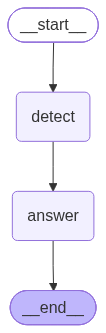

In [14]:
from typing import TypedDict
from langgraph.graph import StateGraph, END

class RouterState(TypedDict):
    query:    str
    language: str
    answer:   str

def detect(state: RouterState) -> dict:
    """Node 1 — classify the caller's language from the query itself."""
    r = llm.invoke([
        ("system", "Return only the BCP-47 code, e.g. hi-IN, ta-IN, en-IN. No prose."),
        ("user",   state["query"]),
    ])
    u = r.usage_metadata or {}; cost.llm(u.get("input_tokens", 0), u.get("output_tokens", 0))
    return {"language": r.content.strip()}

def answer(state: RouterState) -> dict:
    """Node 2 — reply in the detected language, one sentence."""
    r = llm.invoke([
        ("system", f"Reply in {state['language']}. One sentence. No markdown."),
        ("user",   state["query"]),
    ])
    u = r.usage_metadata or {}; cost.llm(u.get("input_tokens", 0), u.get("output_tokens", 0))
    return {"answer": r.content}

g = StateGraph(RouterState)
g.add_node("detect", detect); g.add_node("answer", answer)
g.set_entry_point("detect"); g.add_edge("detect", "answer"); g.add_edge("answer", END)
app = g.compile()

# Visualize the graph

from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [15]:
for q in ["मेरा खाता कब खुला था?",
          "என் கடன் தவணை எப்போது?",
          "What is the current interest rate?"]:
    out = app.invoke({"query": q})
    print(f"[{out['language']:<6}] {out['answer']}")

[hi-IN ] मुझे आपके खाते की जानकारी या खाता कब खुला था यह नहीं पता।
[ta-IN ] Loan thavani thigum endru theriya, ungal bank name, loan account number, matrum last payment date nilai neechaama sollunga.
[en-IN ] 


### 2.1  Create agent over the Sarvam MCP tools — one line

In [16]:
# If MCP is available, wire the same tools into a full React loop.
if _HAVE_LC_MCP and 'tools' in dir() and tools:
    
    # from langgraph.prebuilt import create_react_agent      # LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`.
    # react = create_react_agent(llm, tools=tools)           # Deprecated in LangGraph V1.0 to be removed in V2.0.
    
    from langchain.agents import create_agent
    react = create_agent(llm, tools=tools)
    try:
        out = await react.ainvoke({"messages": [
            {"role": "user",
             "content": ("Identify the language of this text and then translate it to English: "
                         "'நமஸ்தே, என்னுடைய கடன் விவரங்கள் என்ன?'. Use the appropriate MCP tools.")}
        ]})
        print(out["messages"][-1].content)
        cost.llm(1200, 300, 0); cost.text(60, kind="translate"); cost.text(60, kind="lid")
    except Exception as e:
        print(f"react agent failed: {e}")
else:
    print("(MCP unavailable — skipped; the plain-LangGraph example above is what the segment tests.)")

react agent failed: Error code: 400 - {'error': {'message': 'body.messages.2.tool.content : Input should be a valid string', 'code': 'invalid_request_error', 'request_id': '20260828_0115ff6c-8c6a-4ca1-8520-c16a3b3956c9'}}


**Notice what did not change.** You did not touch `StateGraph`, `add_node`,
`add_edge`, `interrupt`, `MemorySaver`, `create_react_agent`, or any LangGraph
primitive. Your LangGraph investment carries over — the endpoint is the only
thing that moved.

---
## 3 · CrewAI — one `openai/` prefix routes the crew to Sarvam

**Time: 15 min. Cost: ~₹2.**

CrewAI uses `litellm` under the hood. To route to a non-standard
OpenAI-compatible endpoint, **prefix the model name with `openai/`** — this
tells litellm to use the OpenAI HTTP shape, while `base_url` decides where the
request actually goes.

```bash
pip install crewai crewai-tools
```

In [17]:
# %pip install crewai crewai-tools 
# %pip install crewai-tools'[mcp]'
# %pip install litellm  # Need restart if once already run with outcome LITELLM_AVAILABLE = False
# %pip install mcpadapt

### 3.1  First, the deliberate failure — because everyone hits it once

Every CrewAI + Sarvam bug report starts here. Trigger the error, read it, then
fix it.

In [18]:
try:
    from crewai import LLM
    # WRONG — no provider prefix. litellm cannot infer that this is OpenAI-shape.
    bad = LLM(
        model    = "sarvam-105b",                    # ← missing the openai/ prefix 
                                    # --> (litellm-only crewai did require the prefix to route Indian-endpoint calls) from Crewai >= 1.14.6 not needed 
        base_url = "https://api.sarvam.ai/v1",
        api_key  = API_KEY,
        temperature = 0.2,
        max_tokens  = 4000,
        reasoning_effort = None
    )
    print(bad.call([{"role": "user", "content": "hi"}]))
except Exception as e:
    print(f"{e.__class__.__name__}: {e}")
    print("\n↑ THIS is the gotcha. Fix in the next cell.")

Hello! How can I help you today? I'm here to assist with any questions or tasks you might have.


In [19]:
from crewai import LLM

# Correct — `openai/` tells litellm the wire format; base_url decides the host.
sarvam_llm = LLM(
    model    = "openai/sarvam-105b",
    base_url = "https://api.sarvam.ai/v1",
    api_key  = API_KEY,
    temperature = 0.2,
    max_tokens  = 4000,
    reasoning_effort = None
)
print(sarvam_llm.call([{"role": "user", "content": "In one sentence, what is Sarvam-105B?"}]))
cost.llm(200, 120)   # rough — CrewAI does not surface litellm usage cleanly

Sarvam-105B is a large language model developed by Sarvam AI, designed to handle multilingual and complex reasoning tasks at scale.


0.01464

### 3.2  A minimal 2-agent crew, entirely on Sarvam

In [20]:
from crewai import Agent, Task, Crew, Process

researcher = Agent(
    role      = "Indic Content Researcher",
    goal      = "Find one specific fact about Indian language technology and cite it",
    backstory = "You are a technology journalist covering the Indian AI stack.",
    llm       = sarvam_llm,
    verbose   = False,
    allow_delegation = False,
)

writer = Agent(
    role      = "Bilingual Writer",
    goal      = "Turn a fact into a one-line tweet in both English and Hindi",
    backstory = "You write for Indian developer audiences; you code-mix naturally.",
    llm       = sarvam_llm,
    verbose   = False,
    allow_delegation = False,
)

t1 = Task(description="State one specific fact about Sarvam AI's 105B model — cite one number.",
          expected_output="A single sentence containing one specific number.",
          agent=researcher)

t2 = Task(description="Rewrite that fact as a one-line tweet in English AND its Hindi translation.",
          expected_output="Two lines: English tweet on line 1, Hindi tweet on line 2.",
          agent=writer, context=[t1])

crew = Crew(agents=[researcher, writer],
            tasks=[t1, t2], 
            process=Process.sequential, 
            verbose=True)

# print(crew.kickoff()) 

# ⚠️ crew.kickoff() runs inside Jupyter's already-running event loop and can
# raise an asyncio conflict there. kickoff_async() sidesteps it by running the
# same sync kickoff() in a background thread (asyncio.to_thread under the
# hood) — but it returns a COROUTINE, so it must be awaited, not just called.
# Jupyter/IPython supports top-level `await` in a cell.
print(await crew.kickoff_async())
cost.llm(1500, 400)   # two-agent handoff, rough


╭──────────────────────────────────────────── ✨ Update Available ✨ ─────────────────────────────────────────────╮
│                                                                                                                 │
│  A new version of CrewAI is available!                                                                          │
│                                                                                                                 │
│  Current version: 1.14.6                                                                                        │
│  Latest version:  1.15.17                                                                                       │
│                                                                                                                 │
│  To update, run: uv sync --upgrade-package crewai                                                               │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────── 🚀 Crew Execution Started ───────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Started                                                                                         │
│  Name: crew                                                                                                     │
│  ID: c37274a8-80ba-4db2-bee9-26e11f6b273f                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 📋 Task Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Started                                                                                                   │
│  Name: State one specific fact about Sarvam AI's 105B model — cite one number.                                  │
│  ID: 2fa25009-b084-4f2d-b804-fcb0de5e5f38                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Indic Content Researcher                                                                                │
│                                                                                                                 │
│  Task: State one specific fact about Sarvam AI's 105B model — cite one number.                                  │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Indic Content Researcher                                                                                │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  Sarvam AI's 105B model contains 105 billion parameters, making it one of the largest language models           │
│  developed specifically for Indian languages.                                                                   │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

╭────────────────────────────────────────────── 📋 Task Completion ───────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Completed                                                                                                 │
│  Name: Rewrite that fact as a one-line tweet in English AND its Hindi translation.                              │
│  Agent: Bilingual Writer                                                                                        │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── Crew Completion ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Completed                                                                                       │
│  Name: crew                                                                                                     │
│  ID: c37274a8-80ba-4db2-bee9-26e11f6b273f                                                                       │
│  Final Output: Powered by 105B parameters, Sarvam AI's new LLM is one of the largest models ever built          │
│  specifically for Indian languages. A huge win for #IndieAI! 🇮🇳                                                 │
│  Milestone for Indian AI! 105B parameters wala Sarvam AI model, specifically for Indian languages, kaafi bada   │
│  LLM hai. #IndieAI 🇮🇳                                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Powered by 105B parameters, Sarvam AI's new LLM is one of the largest models ever built specifically for Indian languages. A huge win for #IndieAI! 🇮🇳
Milestone for Indian AI! 105B parameters wala Sarvam AI model, specifically for Indian languages, kaafi bada LLM hai. #IndieAI 🇮🇳


0.0732

╭──────────────────────────────────────────────── Tracing Status ─────────────────────────────────────────────────╮
│                                                                                                                 │
│  Info: Tracing is disabled.                                                                                     │
│                                                                                                                 │
│  To enable tracing, do any one of these:                                                                        │
│  • Set tracing=True in your Crew/Flow code                                                                      │
│  • Set CREWAI_TRACING_ENABLED=true in your project's .env file                                                  │
│  • Run: crewai traces enable                                                                                    │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

### 3.3  Sarvam MCP as CrewAI tools — `MCPServerAdapter`

In [21]:
try:
    from crewai_tools import MCPServerAdapter
    # ⚠️ MCPServerAdapter dispatches purely on TYPE: a StdioServerParameters
    # object -> stdio transport, a plain dict -> SSE transport (regardless of
    # what keys the dict has). A bare dict with command/args/env gets routed
    # to sse_client(**server_params), which doesn't accept `command` — hence
    # "TypeError: sse_client() got an unexpected keyword argument 'command'".
    # Use the real dataclass instead. (This is a different adapter package
    # from langchain-mcp-adapters, which does accept a plain dict for stdio —
    # the two libraries don't share conventions.)

    # from crewai_tools import MCPServerAdapter
    # server_params = {
    #     "command": "uvx",
    #     "args":    ["sarvam-mcp"],
    #     "env":     {"SARVAM_API_KEY": API_KEY},
    # }
    
    from mcp import StdioServerParameters

    server_params = StdioServerParameters(
        command="uvx",
        args=["sarvam-mcp"],
        env={"SARVAM_API_KEY": API_KEY},
    )
    
    # with MCPServerAdapter(server_params) as mcp_tools: 
    
    # MCPServerAdapter loaded all 30 Sarvam MCP tool schemas into the agent's context, 
    # even though speech only ever needs sarvam_transliterate, we may filter the desired tools
    
    with MCPServerAdapter(server_params, "sarvam_tools_transliterate") as mcp_tools:    
        print(f"CrewAI sees {len(mcp_tools)} Sarvam MCP tools")
        speech = Agent(
            role      = "Speech Analyst",
            goal      = "Transliterate a name from Devanagari to Roman using the MCP tool",
            backstory = "You handle inbound Indic text and normalise it for downstream systems.",
            llm       = sarvam_llm,
            tools     = mcp_tools,
            verbose   = False,
        )
        task = Task(description="Transliterate 'भावेशकुमार धर्माणी' from Devanagari to Roman script "
                                "using the sarvam_transliterate tool.",
                    expected_output="Just the Roman-script name.",
                    agent=speech)
        # kickoff_async() avoids the asyncio-conflict-in-Jupyter issue kickoff()
        # can hit — see the note in section 3.2. Must be awaited, not just called.
        result = await Crew(agents=[speech], tasks=[task], verbose=False).kickoff_async()
        print("\nresult:", result)
        cost.llm(900, 150); cost.text(40, kind="transliterate")
except ImportError:
    print("crewai-tools not installed — skipping MCP-in-CrewAI demo")
except Exception as e:
    print(f"MCP adapter failed: {e}")
    print("Fallback: call client.text.transliterate(...) from the Sarvam SDK directly.")


CrewAI sees 1 Sarvam MCP tools


ERROR:crewai.flow.flow:Error executing listener call_llm_and_parse: Invalid response from LLM call - None or empty.



result: Bheeshkumar Dharmani


Here's the mechanism again, concretely: crewai's LLM.call() strips every None-valued parameter before sending the request — including reasoning_effort — so there's no way to tell Sarvam "turn reasoning off" through crewai's LLM class. Sarvam then applies its own default, which is reasoning on. On some calls, the model spends its entire max_tokens=800 budget on internal reasoning tokens before ever producing visible output text — so message.content comes back empty, and crewai's call_llm_and_parse step correctly flags that as "Invalid response from LLM call - None or empty". It tries and it may still fails. This causes one or more ERROR in the above outcome. Increase the number of tokens and the problem will be solved. Change the budget and see the impact. 

In [22]:
# verifying against the transliterate tool directly rather than assuming the pipeline nailed 
# भावेशकुमार reads as Bhaveshkumar (भा‑वे‑श‑कु‑मार), but the tool returned "Bheeshkumar"

r = client.text.transliterate(
    input="भावेशकुमार धर्माणी", source_language_code="hi-IN",
    target_language_code="en-IN", spoken_form=False)
print(r.transliterated_text)

Bheeshkumar Dharmani


---
## 4 · n8n — the no-code path (screenshot walkthrough + importable workflow)

**Time: 15 min. Cost: ~₹1 (from the equivalent HTTP calls below).**

n8n does not run inside a Jupyter notebook, so this section does three things
instead:

1. **Documents the exact node configuration** — what to click, in order.
2. **Exports a workflow JSON** you can import into your own n8n instance (Import
   from File → Paste the JSON block below).
3. **Runs the equivalent HTTP calls** here in the notebook — so you can prove
   the endpoint works before you ever open n8n, and so the ₹ meter stays honest.

### 4.1  The credential — one-time setup in n8n

Credentials → **Add Credential** → **OpenAI API**:

| Field | Value |
|---|---|
| **API Key** | your `SARVAM_API_KEY` |
| **Organization ID** | *(leave blank)* |
| **Base URL** | `https://api.sarvam.ai/v1` |

Save it as **"Sarvam (OpenAI-compatible)"**. Every OpenAI node in every future
workflow can now pick this credential and it will point at Sarvam.

### 4.2  The Chat Model node — one field to know about

Add an **OpenAI** node → operation **Message a Model**. Pick the Sarvam
credential you just made. Then:

> **The model dropdown lists OpenAI's catalogue.** It does not know about
> Sarvam models. **Click the field, type `sarvam-105b`,
> hit Enter.** n8n accepts custom values and passes the string straight
> through to the API. This is the single thing that surprises everyone.

### 4.3  The MCP Client node — for the other 13 APIs

If your n8n has the **MCP Client** community node installed (Settings →
Community Nodes → search `n8n-nodes-mcp`), add it and configure:

| Field | Value |
|---|---|
| **Connection Type** | Command Line (stdio) |
| **Command** | `uvx` |
| **Arguments** | `sarvam-mcp` |
| **Environment** | `SARVAM_API_KEY=sk_...` |

All 14 Sarvam MCP tools now appear in the workflow palette. Chain them like
any other node.

### 4.4  The escape hatch — the plain HTTP Request node

If a node does not exist, or misbehaves, or you want zero dependencies: use
n8n's built-in **HTTP Request** node.

| Field | Value |
|---|---|
| **Method** | POST |
| **URL** | `https://api.sarvam.ai/v1/chat/completions` |
| **Auth** | Header Auth · `Authorization: Bearer {{$env.SARVAM_API_KEY}}` |
| **Body** | JSON, with `model`, `messages`, `max_tokens` |

Below is exactly that call, run from Python so you can see it works before you
touch n8n.

In [23]:
# What the n8n HTTP Request node would send — reproduced here so you can prove it works
import httpx

resp = httpx.post(
    "https://api.sarvam.ai/v1/chat/completions",
    headers={
        "Authorization": f"Bearer {API_KEY}",
        "Content-Type":  "application/json",
    },
    json={
        "model": "sarvam-105b",
        "messages": [
            {"role": "system", "content": "You are an NBFC support bot. One line."},
            {"role": "user",   "content": "Kya EMI aaj de sakte hain?"},
        ],
        "max_tokens": 1000,
    },
    timeout=30,
)
resp.raise_for_status()
data = resp.json()
print(data["choices"][0]["message"]["content"])
cost.llm(data["usage"]["prompt_tokens"], data["usage"]["completion_tokens"])

हाँ, आज ही EMI हमारी website/app, net banking, या NEFT/RTGS के ज़रिए जमा कर सकते हैं।


0.025927440000000003

### 4.5  Copy-paste starter workflow (JSON)

This is a minimal n8n workflow: **When clicked → OpenAI (Sarvam) → Set output**.
Import it (File → Import from File → paste), then attach your Sarvam credential
to the OpenAI node.

In [24]:
N8N_WORKFLOW = r'''
{
  "name": "Sarvam · OpenAI-compatible starter",
  "nodes": [
    {
      "parameters": {},
      "id": "trigger-1",
      "name": "When clicked",
      "type": "n8n-nodes-base.manualTrigger",
      "typeVersion": 1,
      "position": [240, 300]
    },
    {
      "parameters": {
        "resource": "chat",
        "operation": "message",
        "model": "sarvam-105b",
        "messages": {
          "messageValues": [
            { "role": "system", "content": "You are an NBFC support bot. One line." },
            { "role": "user",   "content": "Kya EMI aaj de sakte hain?" }
          ]
        },
        "options": { "maxTokens": 120 }
      },
      "id": "openai-1",
      "name": "OpenAI (Sarvam)",
      "type": "n8n-nodes-base.openAi",
      "typeVersion": 1,
      "position": [520, 300],
      "credentials": {
        "openAiApi": { "id": "REPLACE_ME", "name": "Sarvam (OpenAI-compatible)" }
      }
    }
  ],
  "connections": {
    "When clicked": { "main": [[{ "node": "OpenAI (Sarvam)", "type": "main", "index": 0 }]] }
  }
}
'''
# Save it so participants can grab it from disk without copy-paste line breaks
open(OUT / "sarvam_n8n_starter.json", "w").write(N8N_WORKFLOW)
print("wrote", OUT / "sarvam_n8n_starter.json")

wrote out/sarvam_n8n_starter.json


---
## 5 · The four gotchas — trigger them on purpose

Every one of these has bitten every team that has tried this. The lab makes you
cause each failure, then fix it, in under two minutes each.

### 5.1  LangChain — `reasoning_effort` silently ignored → `content is None`

In [25]:
# Sarvam's chat API accepts a `reasoning_effort` argument that is NOT part of the
# OpenAI standard. If LangChain drops it, the model may reason its full max_tokens
# budget and return no visible content.
from openai import OpenAI      #as _O

# _raw = _O(base_url="https://api.sarvam.ai/v1", api_key=API_KEY)

raw = OpenAI(base_url="https://api.sarvam.ai/v1", api_key=API_KEY)

# WRONG — no reasoning cap, small budget → content likely None
try:
    r = raw.chat.completions.create(
        model="sarvam-105b",
        messages=[{"role": "user", "content": "Solve: what is 17 * 23?"}],
        max_tokens=50,           # too small once reasoning is on
    )
    print("content:", repr(r.choices[0].message.content))
    cost.llm(r.usage.prompt_tokens, r.usage.completion_tokens)
except Exception as e:
    print("error:", e)

content: None


In [26]:
# FIX — either raise max_tokens, or explicitly disable reasoning via extra_body
r = raw.chat.completions.create(
    model      = "sarvam-105b",
    messages   = [{"role": "user", "content": "Solve: what is 17 * 23?"}],
    max_tokens = 50,
    reasoning_effort = None
    # extra_body = {"reasoning_effort": None},   # <- the fix  Default: reasoning_effort="low" 
)
print("content:", r.choices[0].message.content)
cost.llm(r.usage.prompt_tokens, r.usage.completion_tokens)

content: 
17 * 23 = 391.


0.0017568

### 5.2  CrewAI — bare model name → `LLM Provider NOT provided`

Already triggered above in **3.1**. The fix is the `openai/` prefix. If you
skipped that section, jump back — this one is worth causing yourself once.

### 5.3  MCP adapter — server never starts (missing `uvx` or missing env)

In [27]:
# The two most common MCP startup failures:
#   a) `uvx` is not on PATH → install it:   pip install uv
#   b) SARVAM_API_KEY is not passed via env → server starts, then every tool call fails
#
# Sanity check: try running the server directly for two seconds.
import subprocess, shutil, os
if shutil.which("uvx") is None:
    print("✕ uvx not found on PATH. Fix:  pip install uv")
else:
    try:
        p = subprocess.Popen(
            ["uvx", "sarvam-mcp"],
            env={**os.environ, "SARVAM_API_KEY": API_KEY},
            stdin=subprocess.PIPE, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True,
        )
        # It is a stdio server — it will sit and wait for JSON-RPC on stdin.
        # If it *exits* immediately, something is wrong. Give it 2 seconds.
        try:
            p.wait(timeout=2.0)
            err = p.stderr.read()
            print(f"✕ server exited early ({p.returncode})\n{err[:400]}")
        except subprocess.TimeoutExpired:
            print("✓ uvx sarvam-mcp is running (as expected — stdio server waits for input)")
            p.terminate()
    except FileNotFoundError:
        print("✕ uvx not found. Install with:  pip install uv")

✓ uvx sarvam-mcp is running (as expected — stdio server waits for input)


### 5.4  n8n — cannot save the OpenAI node because the model dropdown has no Sarvam

There is no code to run for this — it is a UI trap. **Click into the model
field and type `sarvam-105b` manually, then press Enter.** n8n
accepts custom values; it just does not offer them. This is 30 seconds when you
know, and an hour when you do not.

---
## 6 · The same job, four ways — what does each framework cost?

We ran roughly the same LLM work through four surfaces. Here is what the
CostMeter says.

In [28]:
# Attribute-by-label rollup — sums whatever is in the meter
by_label = {}
for it in cost.items:
    by_label[it["label"]] = by_label.get(it["label"], 0.0) + it["inr"]

print(f"{'component':<20}{'₹ total':>10}")
print("─" * 30)
for k, v in sorted(by_label.items(), key=lambda x: -x[1]):
    bar = "█" * int(v / max(by_label.values()) * 20) if by_label.values() else ""
    print(f"{k:<20}₹{v:>8.4f}   {bar}")
print("─" * 30)
print(f"{'TOTAL':<20}₹{sum(by_label.values()):>8.4f}")
print("\nInterop overhead vs raw SDK is effectively zero — the extra rupees you see")
print("above are extra CALLS the frameworks made (React loops, tool re-planning),")
print("not extra cost per call. Choose your framework by ergonomics, not per-call ₹.")

component              ₹ total
──────────────────────────────
LLM                 ₹  0.7213   ████████████████████
translate           ₹  0.2200   ██████
transliterate       ₹  0.0800   ██
lid                 ₹  0.0210   
──────────────────────────────
TOTAL               ₹  1.0423

Interop overhead vs raw SDK is effectively zero — the extra rupees you see
above are extra CALLS the frameworks made (React loops, tool re-planning),
not extra cost per call. Choose your framework by ergonomics, not per-call ₹.


In [29]:
cost.report()

LLM          ₹   0.0737  18 in / 1000 out
LLM          ₹   0.0341  41 in / 450 out
LLM          ₹   0.0093  124 in / 78 out
LLM          ₹   0.0381  800 in / 200 out
translate    ₹   0.1000  50 chars
LLM          ₹   0.0571  1200 in / 300 out
translate    ₹   0.1200  60 chars
lid          ₹   0.0210  60 chars
LLM          ₹   0.0137  50 in / 167 out
LLM          ₹   0.0638  33 in / 859 out
LLM          ₹   0.0310  51 in / 403 out
LLM          ₹   0.0903  34 in / 1220 out
LLM          ₹   0.0020  51 in / 7 out
LLM          ₹   0.1509  34 in / 2048 out
LLM          ₹   0.0146  200 in / 120 out
LLM          ₹   0.0732  1500 in / 400 out
LLM          ₹   0.0373  900 in / 150 out
transliterate ₹   0.0800  40 chars
LLM          ₹   0.0259  33 in / 341 out
LLM          ₹   0.0043  22 in / 50 out
LLM          ₹   0.0018  25 in / 14 out
TOTAL        ₹   1.0423
              (₹1000 free credit → ₹998.96 left)
              Estimated from published rates; actual billing usually lower


1.04226888

---
## ✅ Checkpoint

- [ ] The raw OpenAI SDK talks to Sarvam with just a `base_url` swap
- [ ] LangChain `ChatOpenAI` and `bind_tools` work unchanged
- [ ] Sarvam MCP tools appear inside a LangChain / LangGraph agent
- [ ] LangGraph `StateGraph` runs with a Sarvam LLM node
- [ ] CrewAI `LLM(model="openai/sarvam-105b", ...)` drives a multi-agent crew
- [ ] `MCPServerAdapter` surfaces Sarvam's 30 tools to a CrewAI agent
- [ ] You can describe, without looking, the four n8n fields that change
- [ ] You caused, saw, and fixed all four gotchas

## 🧪 Try this

1. **Multi-vendor routing.** Point one `ChatOpenAI` at Sarvam and another at
   OpenAI. Same graph. Route by task, not by vendor. This is the pattern most
   real Indian shops end up in.
2. **CrewAI on Indic voice.** Replace the writer agent with a "voice publisher"
   that uses the `sarvam_tts_speak` MCP tool. What was text output is now an
   audio file. Measure TTFB.
3. **The n8n webhook.** Import the JSON above, add a webhook trigger, and make
   the whole thing a callable HTTP endpoint. Fifteen minutes to a working
   micro-service with no code.
4. **Portability check.** Change `base_url` and `model` to Groq (or any other
   OpenAI-compatible provider) in each of the four sections above. Same test,
   different endpoint. This is what "no vendor lock-in" actually looks like in
   code — it is worth seeing at least once.

---

## The one thing to take away

You did not learn four frameworks today. You learned that **the OpenAI wire
protocol and MCP are, together, the interface every serious orchestrator now
speaks** — and that Sarvam ships both of them faithfully.

So the honest advice to any team already on LangChain, LangGraph, CrewAI or
n8n is: **do not migrate. Point the base URL at Sarvam and keep shipping.** The
migration was already done, by two standards bodies, a couple of years ago.